In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("cardiotocographic.csv")

In [3]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


#### Task 1.	Data Cleaning and Preparation:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [11]:
# Dropping the Null Values
df = df.dropna()

In [7]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [8]:
df.duplicated().sum()

2

In [12]:
# Dropping the Duplicates
df = df.drop_duplicates(ignore_index = True)

In [10]:
df.duplicated().sum()

0

<Axes: >

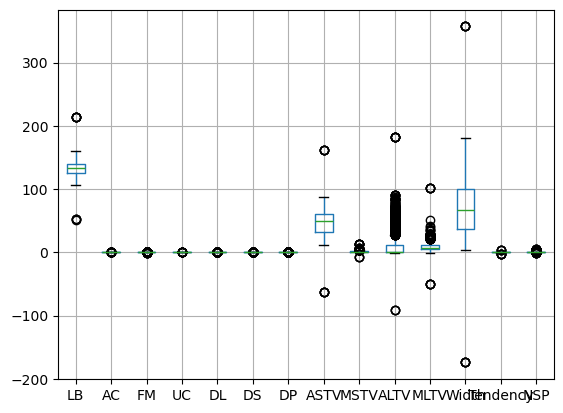

In [13]:
# Outlier Detection
df.boxplot()

In [14]:
### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

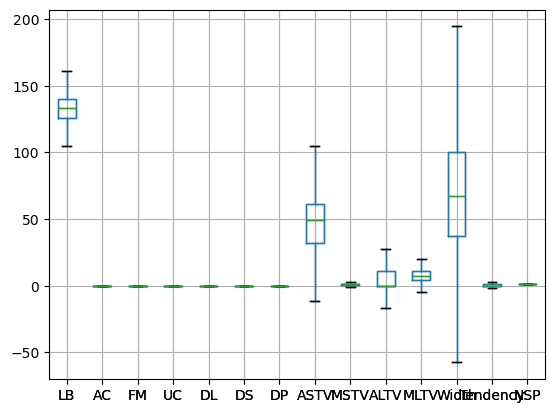

In [16]:
df.boxplot()
plt.show()

#### Task 2.	Statistical Summary:

In [19]:
# Statistical Summary using agg()

summary_agg = df.agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
summary_agg['iqr'] = df.quantile(0.75) - df.quantile(0.25)

print("📊 Statistical Summary using agg():\n")
display(summary_agg)

# Mean and median are close for most variables — indicating low skewness.

📊 Statistical Summary using agg():



,count,mean,median,std,min,max,iqr
LB,2103.0,133.291604,133.000000,9.976211,105.000000,161.000000,14.000000
AC,2103.0,0.003144,0.001631,0.003844,-0.008475,0.014124,0.005650
FM,2103.0,0.001565,0.000000,0.002477,-0.003839,0.006398,0.002559
UC,2103.0,0.004361,0.004484,0.003008,-0.005219,0.013601,0.004705
DL,2103.0,0.001770,0.000000,0.002675,-0.004942,0.008237,0.003295
DS,2103.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DP,2103.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASTV,2103.0,46.999304,49.000000,17.633594,-11.500000,104.500000,29.000000
MSTV,2103.0,1.301912,1.200000,0.779896,-0.800000,3.200000,1.000000
ALTV,2103.0,6.733464,0.000000,10.400402,-16.500000,27.500000,11.000000


#### Task 3.	Data Visualization:

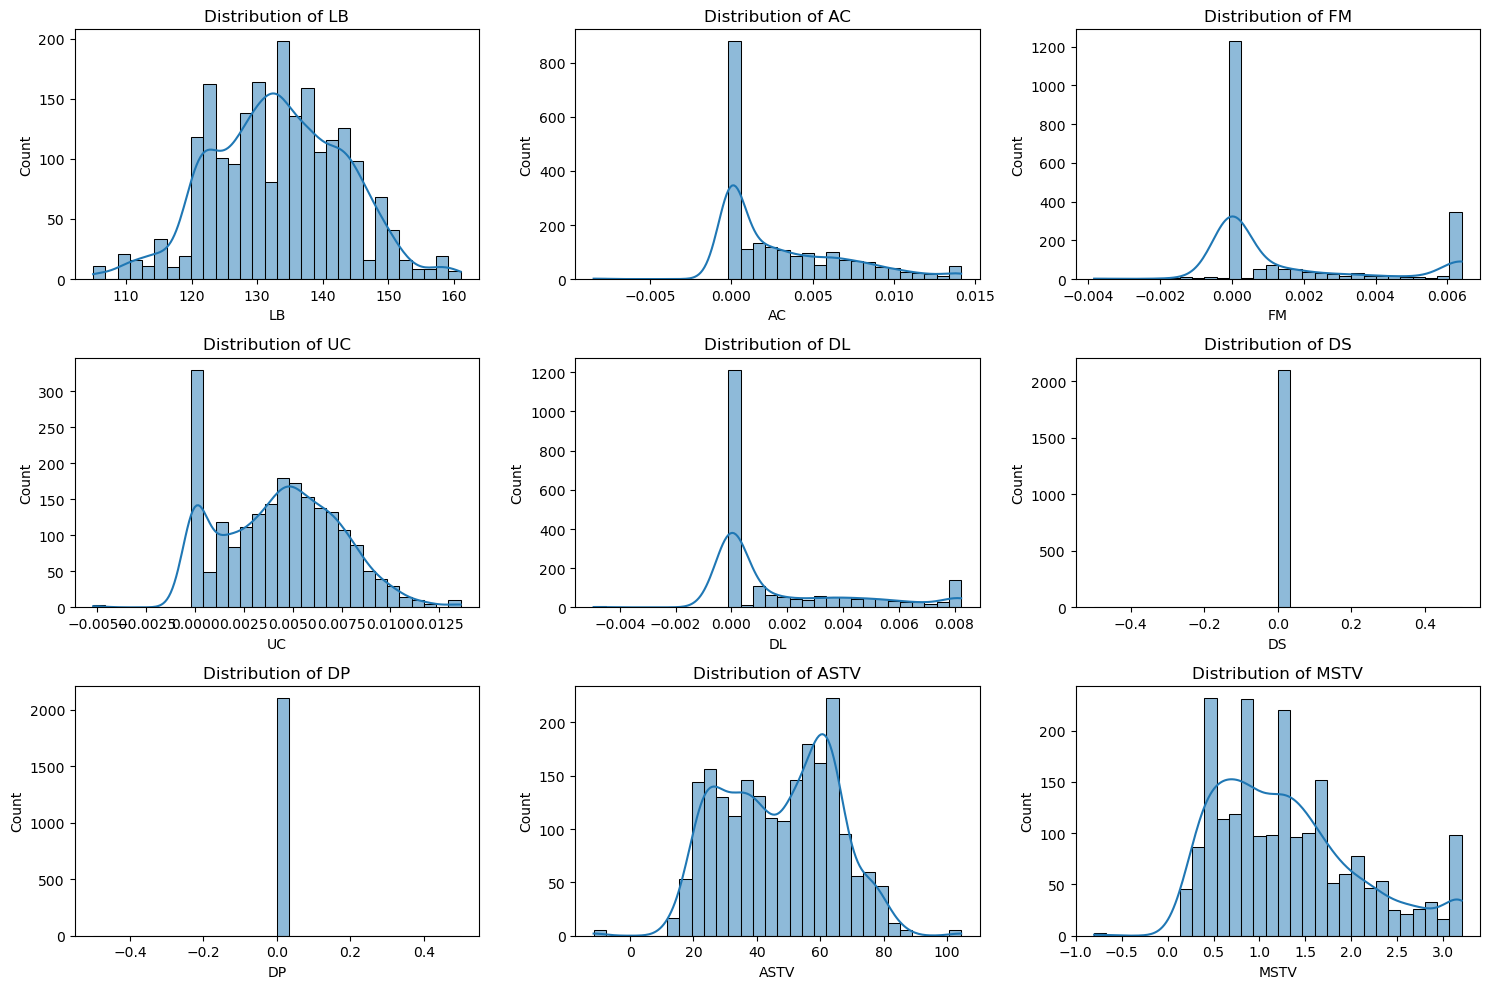

In [30]:
### Histogram
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:9], 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

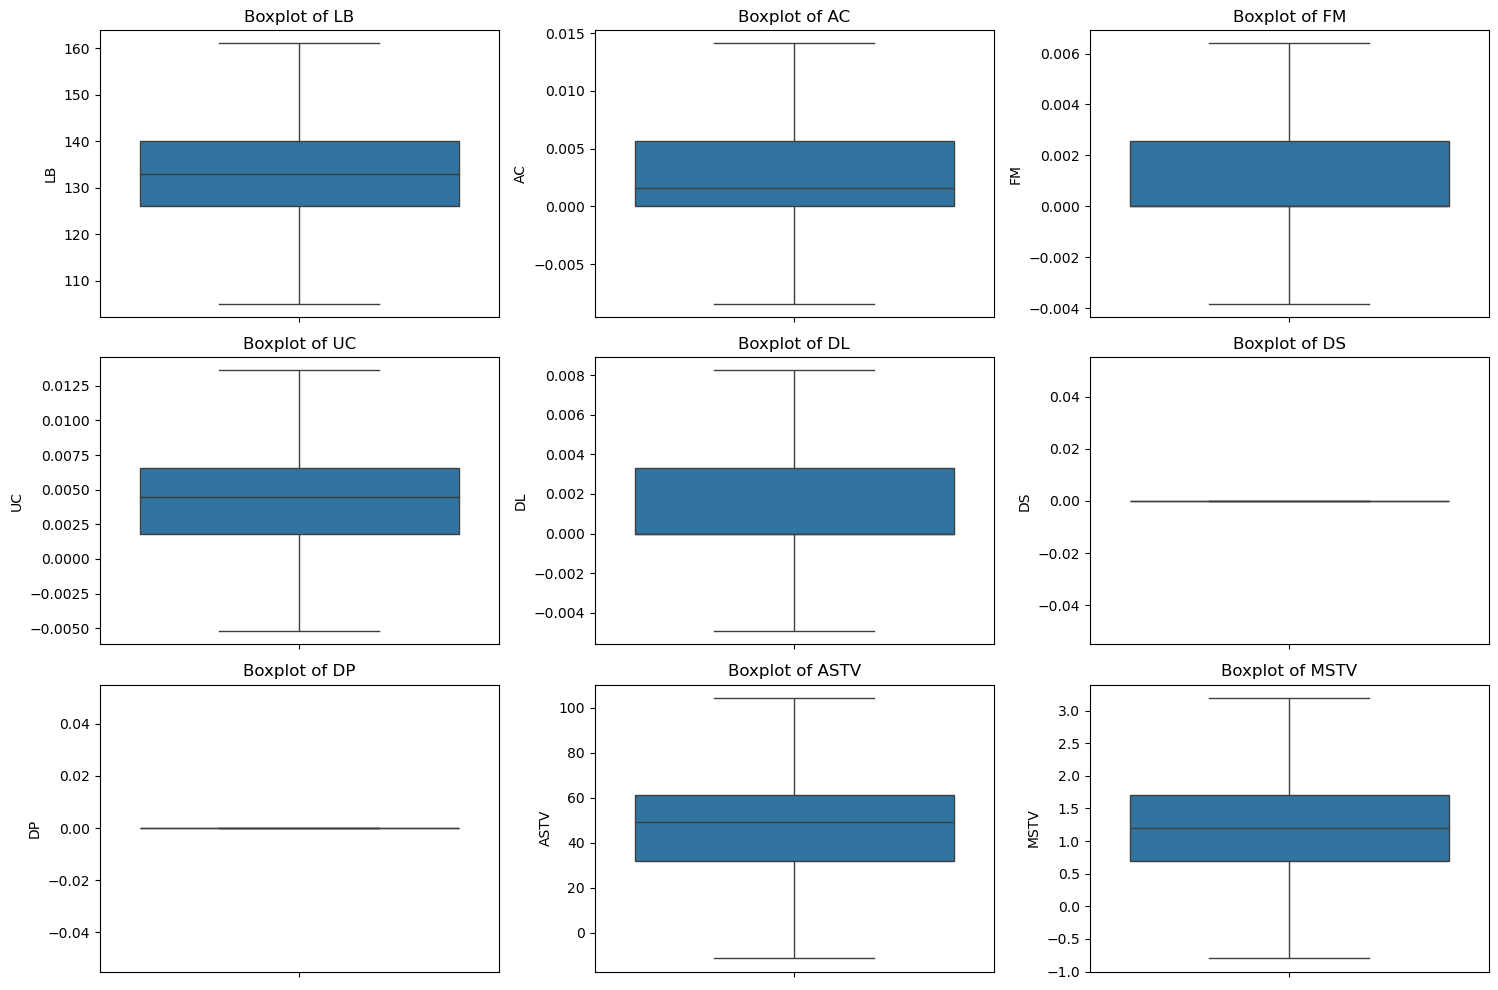

In [29]:
### BOXPLOTS FOR OUTLIERS
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:9], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

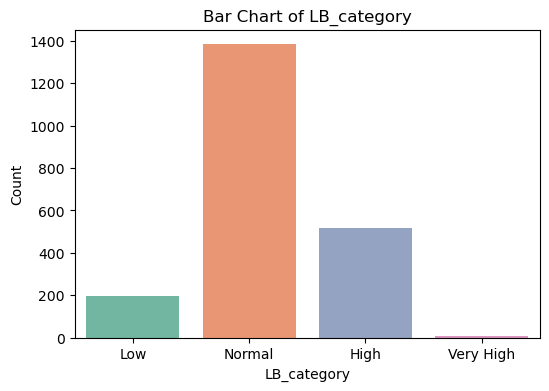

In [40]:
### BAR CHART FOR CATEGORICAL FEATURES

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(cat_cols) > 0:
    for col in cat_cols:
        plt.figure(figsize=(6,4))
        sns.countplot(x=df[col], palette='Set2')
        plt.title(f"Bar Chart of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

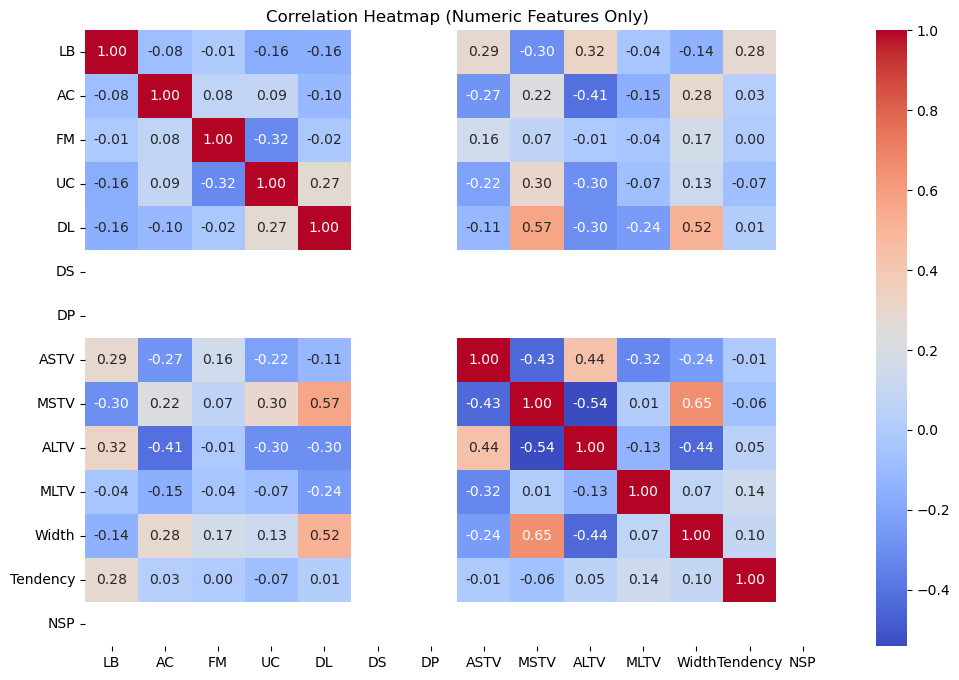

In [45]:
numeric_df = df.select_dtypes(include=['number'])

### Calculate correlation matrix
corr = numeric_df.corr()

### Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

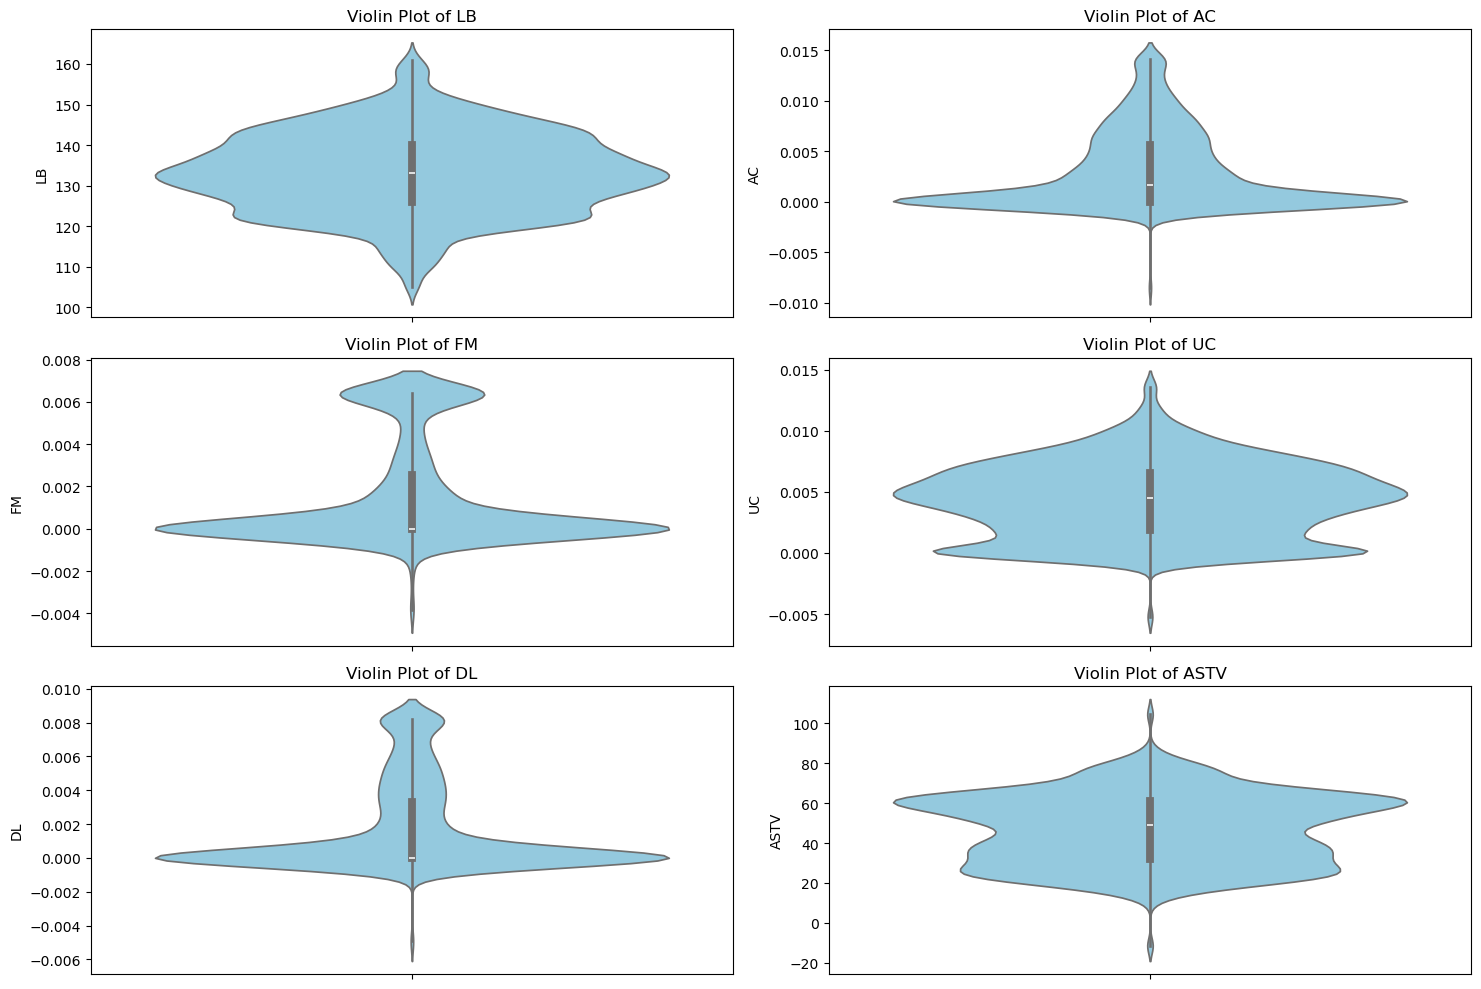

In [48]:
### VIOLIN PLOTS
selected_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'ASTV', 'ALTV', 'MSTV', 'MLTV']
plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_features[:6], 1):
    plt.subplot(3, 2, i)
    sns.violinplot(y=df[col], color='skyblue')
    plt.title(f"Violin Plot of {col}")
plt.tight_layout()
plt.show()

#### Task 4.	Pattern Recognition and Insights:

In [52]:
print("Feature Correlations with Baseline Fetal Heart Rate (LB):\n")
for col in selected_features:
    if col != 'LB':
        print(f"{col}: {df['LB'].corr(df[col]):.2f}")

# LB (Baseline Heart Rate) is positively correlated with AC (Accelerations) and FM (Fetal Movements) — a sign of fetal well-being.
# DL, DS, and DP (Decelerations) show weaker or negative correlation with LB — possible fetal stress indicators.

Feature Correlations with Baseline Fetal Heart Rate (LB):

AC: -0.08
FM: -0.01
UC: -0.16
DL: -0.16
ASTV: 0.29
ALTV: 0.32
MSTV: -0.30
MLTV: -0.04


#### Task 5. Conclusion

In [53]:
print("1. Data was cleaned and prepared successfully — missing values handled and outliers capped.")
print("2. Statistical summary shows well-behaved variables with few extreme cases.")
print("3. Visualization highlights correlations between accelerations, variability, and fetal well-being.")
print("4️. ASTV and ALTV show strong correlation, reflecting consistency between short- and long-term variability.")
print("5️. Dataset is now ready for further modeling — classification of fetal states or risk prediction.")

1. Data was cleaned and prepared successfully — missing values handled and outliers capped.
2. Statistical summary shows well-behaved variables with few extreme cases.
3. Visualization highlights correlations between accelerations, variability, and fetal well-being.
4️. ASTV and ALTV show strong correlation, reflecting consistency between short- and long-term variability.
5️. Dataset is now ready for further modeling — classification of fetal states or risk prediction.
